# Loading the dataset

In [13]:
import numpy as np
import pandas as pd

In [14]:
df =  pd.read_csv('/content/placement.csv')

In [15]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


# Preprocessiong

In [17]:
# Removing 1st column
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# EDA

In [20]:
import matplotlib.pyplot as plt

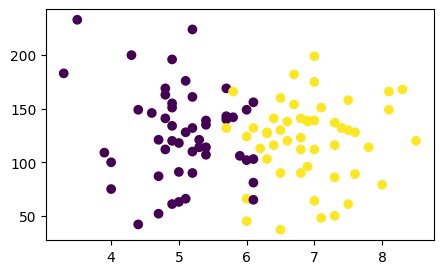

In [30]:
plt.figure(figsize=(5,3))
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

# Extrating input and output columns

In [43]:
X = df.iloc[:,0:2]
y =df.iloc[:,-1]


In [40]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [41]:
X.shape

(100, 2)

In [44]:
y.head()

,placement
0,1
1,0
2,0
3,1
4,0


In [45]:
y.shape

(100,)

# Tain Test Split

In [46]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [50]:
X_train

,cgpa,iq
17,3.3,183.0
79,6.5,90.0
52,7.0,175.0
74,6.7,154.0
6,5.7,143.0
...,...,...
15,5.1,176.0
98,6.3,103.0
33,6.0,149.0
24,4.7,121.0


In [51]:
y_train

,placement
17,0
79,1
52,1
74,1
6,0
...,...
15,0
98,1
33,0
24,0


# Standardizing the data to ensure all features are on the same scale.


In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()

In [60]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Since the data is clearly separable, we are using Logistic Regression for classification.


In [61]:
from sklearn.linear_model import LogisticRegression

In [73]:
clf = LogisticRegression()

# Model training

In [74]:
model = clf.fit(X_train,y_train)

# Model Evaluation

In [75]:
y_pred = model.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score

In [77]:
accuracy_score(y_test, y_pred)

0.9

# Plotting decision regions


In [78]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

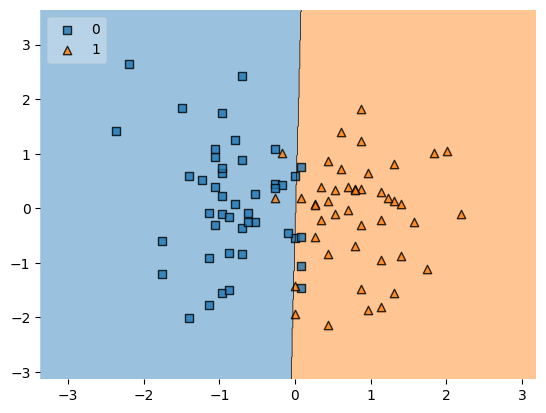

In [83]:
plot_decision_regions(X_train, y_train.values, clf=model, legend=2)

In [80]:
import pickle

In [84]:
pickle.dump(model, open('model.pkl', 'wb'))